# Project:E-commerce Order Analytics (2020-2024)

### Ingest & Understand Data

In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\satya\Downloads\Project E commerce Order Analytics (2020–2024) Python\Project E commerce Order Analytics (2020–2024) Python\Amazon.csv")

In [4]:
print(df.columns.tolist())

['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID']


In [5]:
print(df.shape)

(100000, 20)


In [6]:
print(df.head())

      OrderID   OrderDate  CustomerID   CustomerName ProductID  \
0  ORD0000001  2023-01-31  CUST001504  Vihaan Sharma    P00014   
1  ORD0000002  2023-12-30  CUST000178    Pooja Kumar    P00040   
2  ORD0000003  2022-05-10  CUST047516    Sneha Singh    P00044   
3  ORD0000004  2023-07-18  CUST030059   Vihaan Reddy    P00041   
4  ORD0000005  2023-02-04  CUST048677  Aditya Kapoor    P00029   

           ProductName        Category       Brand  Quantity  UnitPrice  \
0           Drone Mini           Books   BrightLux         3     106.59   
1           Microphone  Home & Kitchen  UrbanStyle         1     251.37   
2  Power Bank 20000mAh        Clothing  UrbanStyle         3      35.03   
3       Webcam Full HD  Home & Kitchen      Zenith         5      33.58   
4              T-Shirt        Clothing    KiddoFun         2     515.64   

   Discount    Tax  ShippingCost  TotalAmount     PaymentMethod OrderStatus  \
0      0.00   0.00          0.09       319.86        Debit Card   Deliver

In [7]:
print(df.dtypes)

OrderID           object
OrderDate         object
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
City              object
State             object
Country           object
SellerID          object
dtype: object


### Clean & Standarize Data

In [9]:
import pandas as pd
df= df = pd.read_csv(r"C:\Users\satya\Downloads\Project E commerce Order Analytics (2020–2024) Python\Project E commerce Order Analytics (2020–2024) Python\Amazon.csv")

In [10]:
df= df.drop_duplicates() 

In [13]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [16]:
df['OrderDate']

0       2023-01-31
1       2023-12-30
2       2022-05-10
3       2023-07-18
4       2023-02-04
           ...    
99995   2023-03-07
99996   2021-11-24
99997   2023-04-29
99998   2021-11-01
99999   2021-12-04
Name: OrderDate, Length: 100000, dtype: datetime64[ns]

In [17]:
for col in ['PaymentMethod', 'OrderStatus']:
    df[col] = df[col].str.strip().str.lower()

In [20]:
df['CalculatedTotal'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount']) + df['Tax'] + df['ShippingCost']

In [21]:
df['CalculatedTotal']

0         319.8600
1         259.6415
2         108.0610
3         159.6650
4         821.3600
           ...    
99995    1066.2000
99996    2432.2900
99997    1016.4000
99998     330.6600
99999     858.5150
Name: CalculatedTotal, Length: 100000, dtype: float64

In [22]:
df['Diff'] = abs(df['TotalAmount'] - df['CalculatedTotal'])
df['Diff']

0        5.684342e-14
1        1.500000e-03
2        1.000000e-03
3        5.000000e-03
4        0.000000e+00
             ...     
99995    0.000000e+00
99996    0.000000e+00
99997    0.000000e+00
99998    5.684342e-14
99999    5.000000e-03
Name: Diff, Length: 100000, dtype: float64

### Feature & Segment 

In [24]:
import pandas as pd
import numpy as np

In [25]:
df= df = pd.read_csv(r"C:\Users\satya\Downloads\Project E commerce Order Analytics (2020–2024) Python\Project E commerce Order Analytics (2020–2024) Python\Amazon.csv")

In [26]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [29]:
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['YearMonth'] = df['OrderDate'].dt.to_period('M')


0        2023-01
1        2023-12
2        2022-05
3        2023-07
4        2023-02
          ...   
99995    2023-03
99996    2021-11
99997    2023-04
99998    2021-11
99999    2021-12
Name: YearMonth, Length: 100000, dtype: period[M]

In [30]:
df['Year']

0        2023
1        2023
2        2022
3        2023
4        2023
         ... 
99995    2023
99996    2021
99997    2023
99998    2021
99999    2021
Name: Year, Length: 100000, dtype: int32

In [31]:
df['Month']

0         1
1        12
2         5
3         7
4         2
         ..
99995     3
99996    11
99997     4
99998    11
99999    12
Name: Month, Length: 100000, dtype: int32

In [32]:
df['YearMonth'] 

0        2023-01
1        2023-12
2        2022-05
3        2023-07
4        2023-02
          ...   
99995    2023-03
99996    2021-11
99997    2023-04
99998    2021-11
99999    2021-12
Name: YearMonth, Length: 100000, dtype: period[M]

In [69]:
df['GrossAmount'] = df['Quantity'] * df['UnitPrice']
df['GrossAmount']

0         319.77
1         251.37
2         105.09
3         167.90
4        1031.28
          ...   
99995     984.68
99996    2246.50
99997     929.60
99998     294.05
99999     833.50
Name: GrossAmount, Length: 100000, dtype: float64

In [37]:
df['DiscountAmount'] = df['GrossAmount'] * df['Discount']
df['NetAmount'] = df['GrossAmount'] - df['DiscountAmount']
df['NetAmount'].round(2)

0         319.77
1         238.80
2          94.58
3         142.71
4         773.46
          ...   
99995     984.68
99996    2246.50
99997     929.60
99998     294.05
99999     791.82
Name: NetAmount, Length: 100000, dtype: float64

In [39]:
df['TaxPct'] = (df['Tax'] / df['NetAmount']) * 100
df['TaxPct'].round(2)

0        0.0
1        8.0
2        8.0
3        8.0
4        5.0
        ... 
99995    8.0
99996    8.0
99997    8.0
99998    8.0
99999    8.0
Name: TaxPct, Length: 100000, dtype: float64

In [40]:
df['DiscountPct'] = df['Discount'] * 100
df['DiscountPct'].round(2)

0         0.0
1         5.0
2        10.0
3        15.0
4        25.0
         ... 
99995     0.0
99996     0.0
99997     0.0
99998     0.0
99999     5.0
Name: DiscountPct, Length: 100000, dtype: float64

In [43]:
print(df[['Year', 'Month', 'GrossAmount', 'NetAmount', 'DiscountPct', 'TaxPct']].head())

   Year  Month  GrossAmount  NetAmount  DiscountPct    TaxPct
0  2023      1       319.77   319.7700          0.0  0.000000
1  2023     12       251.37   238.8015          5.0  7.998275
2  2022      5       105.09    94.5810         10.0  8.003722
3  2023      7       167.90   142.7150         15.0  8.001962
4  2023      2      1031.28   773.4600         25.0  4.999612


In [47]:
def segment_summary(group_col):
    summary = df.groupby(group_col).agg({
        'FinalAmount': ['sum', 'mean', 'count'],
        'GrossAmount': 'sum',
        'DiscountAmount': 'sum',
        'NetAmount': 'sum',
        'Quantity': 'sum'
    }).round(2)
    summary.columns = ['Revenue', 'AOV', 'Orders', 'GrossSales', 'TotalDiscount', 'NetSales', 'Units']
    return summary.sort_values('Revenue', ascending=False).head(10)


In [54]:
print(" SEGMENT BY CATEGORY ")
print(segment_summary('Category'))

 SEGMENT BY CATEGORY 
                       Revenue     AOV  Orders   GrossSales  TotalDiscount  \
Category                                                                     
Electronics        15584217.67  924.71   16853  15432682.26     1144068.07   
Sports & Outdoors  15345572.12  913.21   16804  15214315.21     1132323.48   
Books              15261837.43  911.05   16752  15129134.02     1132719.46   
Clothing           15253398.33  927.88   16439  15126422.24     1127569.86   
Toys & Games       15216685.28  919.88   16542  15087879.05     1117829.39   
Home & Kitchen     15163939.16  912.94   16610  15030780.21     1128608.91   

                      NetSales  Units  
Category                               
Electronics        14288614.19  50696  
Sports & Outdoors  14081991.73  50543  
Books              13996414.56  49981  
Clothing           13998852.38  49523  
Toys & Games       13970049.66  49773  
Home & Kitchen     13902171.30  49624  


In [55]:
print(" SEGMENT BY PAYMENTMETHOD ")
print(segment_summary('PaymentMethod'))

 SEGMENT BY PAYMENTMETHOD 
                      Revenue     AOV  Orders   GrossSales  TotalDiscount  \
PaymentMethod                                                               
Credit Card       32122158.71  916.78   35038  31844238.44     2381095.99   
Debit Card        18538679.42  925.82   20024  18362051.08     1344643.83   
UPI               13896029.03  922.34   15066  13771381.44     1019962.06   
Amazon Pay        13697498.41  912.13   15017  13596399.88     1028476.72   
Net Banking        9055674.86  912.23    9927   8972538.57      676816.61   
Cash on Delivery   4515609.54  916.32    4928   4474603.58      332123.98   

                     NetSales   Units  
PaymentMethod                          
Credit Card       29463142.45  105046  
Debit Card        17017407.25   60242  
UPI               12751419.38   45218  
Amazon Pay        12567923.16   45099  
Net Banking        8295721.96   29699  
Cash on Delivery   4142479.60   14836  


In [61]:
print("SEGMENT BY ORDERSTATUS ")
print(segment_summary('OrderStatus'))

SEGMENT BY ORDERSTATUS 
                 Revenue     AOV  Orders   GrossSales  TotalDiscount  \
OrderStatus                                                            
Delivered    68372678.46  916.18   74628  67807347.44     5076043.88   
Shipped      14083629.48  927.04   15192  13929943.24     1016477.91   
Pending       3737557.08  910.93    4103   3710966.13      279790.83   
Cancelled     2851122.41  941.59    3028   2814736.66      202196.36   
Returned      2780662.54  911.99    3049   2758219.52      208610.21   

                NetSales   Units  
OrderStatus                       
Delivered    62731303.56  223759  
Shipped      12913465.33   45660  
Pending       3431175.30   12338  
Cancelled     2612540.30    9242  
Returned      2549609.31    9141  


In [57]:
print(" SEGMENT BY COUNTRY ")
print(segment_summary('Country'))

 SEGMENT BY COUNTRY 
                    Revenue     AOV  Orders   GrossSales  TotalDiscount  \
Country                                                                   
United States   64310050.64  917.95   70058  63746228.16     4752211.89   
India           13875838.99  921.92   15051  13737728.01     1009473.00   
Canada           5323757.03  915.05    5818   5283259.18      397626.10   
United Kingdom   4526896.86  915.82    4943   4494987.10      339158.92   
Australia        3789106.45  917.46    4130   3759010.54      284649.28   

                   NetSales   Units  
Country                              
United States   58994016.27  210409  
India           12728255.01   45082  
Canada           4885633.08   17381  
United Kingdom   4155828.18   14831  
Australia        3474361.26   12437  


In [58]:
print("SEGMENT BY SELLERID (Top 10)")
print(segment_summary('SellerID'))


SEGMENT BY SELLERID (Top 10)
            Revenue      AOV  Orders  GrossSales  TotalDiscount  NetSales  \
SellerID                                                                    
SELL00806  71283.65  1063.94      67    70146.50        4312.29  65834.21   
SELL00440  71062.64  1164.96      61    70413.19        4945.24  65467.95   
SELL01225  70785.96  1160.43      61    68018.29        3795.96  64222.33   
SELL00709  70491.93  1021.62      69    69336.24        5215.31  64120.93   
SELL00221  70446.48  1083.79      65    69719.18        4973.02  64746.16   
SELL01122  69469.40  1036.86      67    70286.91        5960.13  64326.78   
SELL00994  69400.04  1137.71      61    69632.73        5950.00  63682.73   
SELL00536  69248.00   989.26      70    68324.63        5179.44  63145.19   
SELL00371  69118.88  1063.37      65    68969.63        6385.17  62584.46   
SELL00812  68591.84  1008.70      68    68103.26        4280.07  63823.19   

           Units  
SellerID          
SELL0080

### Core Analysis

In [76]:
print("Sales KPI for Total Revenue")
total_revenue = df['TotalAmount'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Sales KPI for Total Revenue
Total Revenue: $91,825,647.92


In [78]:
print("Sales KPI for Average Order Value")
aov = df['TotalAmount'].mean()
print(f"Avg Order Value (AOV): ${aov:.2f}")

Sales KPI for Average Order Value
Avg Order Value (AOV): $918.26


In [81]:
print("Sales KPI for Total Orders")
order = len(df)
print(f"Total Orders:{order:,}")

Sales KPI for Total Orders
Total Orders:100,000


In [84]:
print("Sale KPI for Total Units Sold")
units = df['Quantity'].sum()
print(f" Total Units Sold : {units:,}")

Sale KPI for Total Units Sold
 Total Units Sold : 300,140


In [86]:
print("Top  Categories by Revenue:")
print(df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False).head())

Top  Categories by Revenue:
Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Name: TotalAmount, dtype: float64


In [88]:
print("Payment Mix (%%) ")
payment_mix= df['PaymentMethod'].value_counts(normalize=True)*100
print(payment_mix.round(2))

Payment Mix (%%) 
PaymentMethod
Credit Card         35.04
Debit Card          20.02
UPI                 15.07
Amazon Pay          15.02
Net Banking          9.93
Cash on Delivery     4.93
Name: proportion, dtype: float64


In [89]:
status_counts = df['OrderStatus'].value_counts()
status_counts

OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: count, dtype: int64

In [109]:
delivery_rate = (status_counts.get('Delivered',0) / len(df)) * 100
delivery_rate


np.float64(74.628)

In [101]:
print(f"Delivery Rate: {delivery_rate:.1f}% ({status_counts.get('Delivered',0):,} Delivered)")

Delivery Rate: 74.6% (74,628 Delivered)


In [103]:
print(f"Returns/Cancellations: {status_counts.get('Returned', 0) + status_counts.get('Cancelled', 0):,}")

Returns/Cancellations: 6,077


In [106]:
print(f" Average Shipping Cost : ${df['ShippingCost'].mean():.2f}")

 Average Shipping Cost : $7.41


In [111]:
print("Geography")
print("\nBy Country:\n" , df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head())
print("\nBy State:\n", df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False).head())

Geography

By Country:
 Country
United States     64310048.50
India             13875839.12
Canada             5323757.00
United Kingdom     4526896.86
Australia          3789106.44
Name: TotalAmount, dtype: float64

By State:
 State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
Name: TotalAmount, dtype: float64


In [116]:
print("\n TIME TRENDS ")
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['YearMonth'] = df['OrderDate'].dt.to_period('M')

print("Yearly Revenue:")
print(df.groupby('Year')['TotalAmount'].sum())
print("\nMonthly Seasonality (by month):")
print(df.groupby('Month')['TotalAmount'].sum())



 TIME TRENDS 
Yearly Revenue:
Year
2020    18529864.02
2021    18248574.81
2022    18367248.41
2023    18513912.19
2024    18166048.49
Name: TotalAmount, dtype: float64

Monthly Seasonality (by month):
Month
1     7883801.27
2     6931724.49
3     7766527.73
4     7646203.22
5     7864283.27
6     7654636.75
7     7737925.51
8     7890598.37
9     7558970.85
10    7654243.32
11    7495754.13
12    7740979.01
Name: TotalAmount, dtype: float64


# Visualize 

### 	Line: Sales by Year

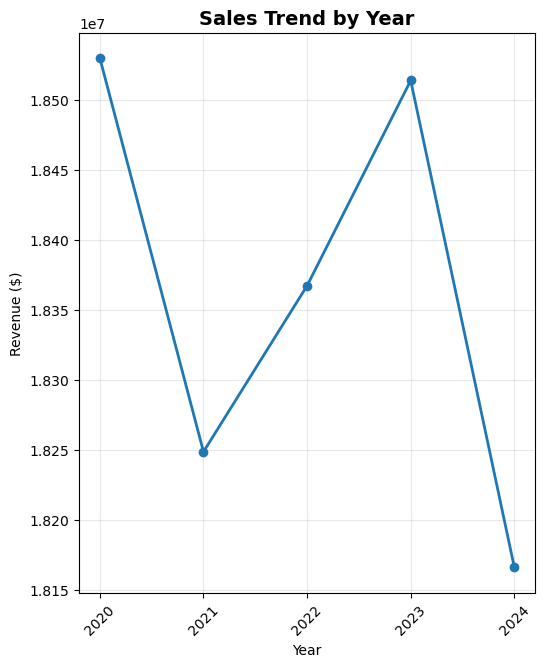

In [120]:
plt.style.use('default')
fig = plt.figure(figsize=(20, 16))

## 1. LINE CHART: Sales by Year
plt.subplot(2, 3, 1)
monthly_sales = df.groupby('Year')['TotalAmount'].sum()
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2, markersize=6)
plt.title('Sales Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

### Bar: Categories

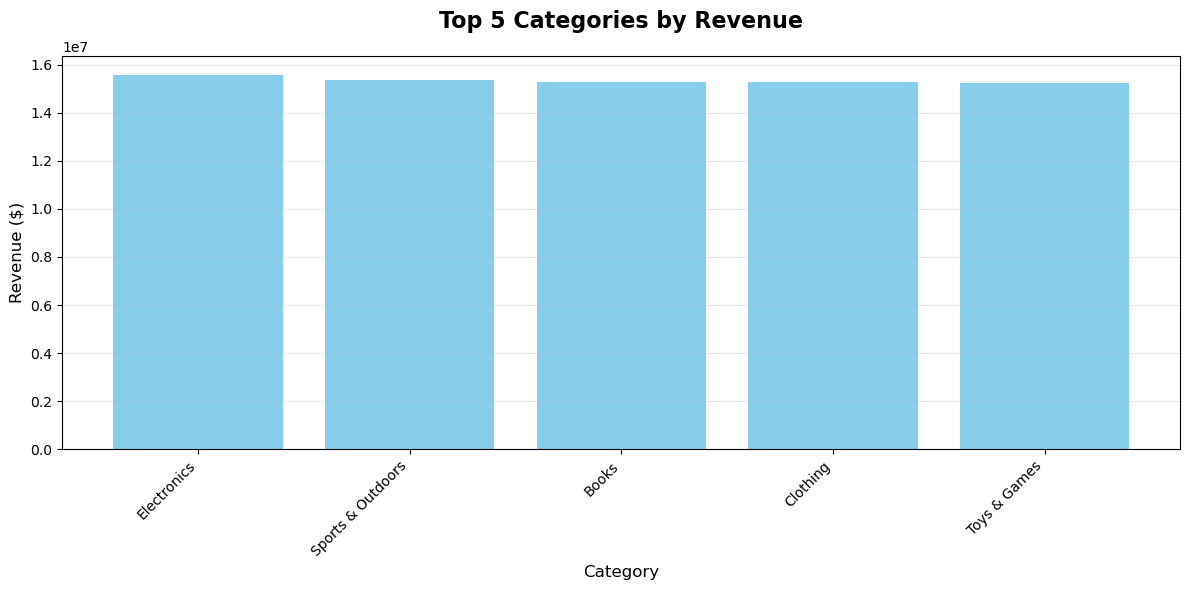

In [124]:
plt.figure(figsize=(12, 6))
top_cats = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False).head(5)
bars = plt.bar(range(len(top_cats)), top_cats.values, color='skyblue')
plt.title('Top 5 Categories by Revenue', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(range(len(top_cats)), top_cats.index, rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25, left=0.1, right=0.95)  
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Stacked Bar: OrderStatus distribution

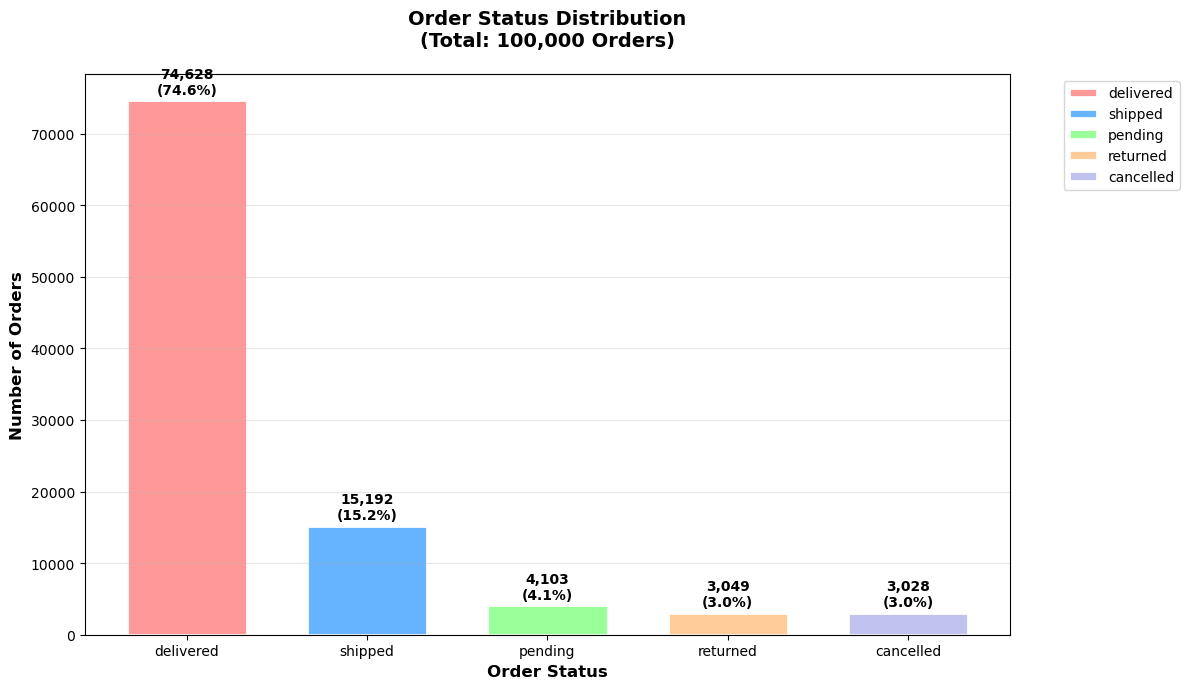

In [132]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['OrderStatus'] = df['OrderStatus'].str.strip().str.lower()
status_counts = df['OrderStatus'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))

positions = [0, 1.2, 2.4, 3.6, 4.8]  # Spaced positions
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']
width = 0.8


for i, (status, count) in enumerate(status_counts.items()):
    ax.bar(positions[i], count, width, label=status, 
           color=colors[i], edgecolor='white', linewidth=2)


ax.set_xlabel('Order Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=12, fontweight='bold')
ax.set_title('Order Status Distribution\n(Total: 100,000 Orders)', 
             fontsize=14, fontweight='bold', pad=20)

for i, (status, count) in enumerate(status_counts.items()):
    ax.text(positions[i], count + 500, f'{count:,}\n({count/len(df)*100:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(positions, status_counts.index, rotation=0)
plt.tight_layout()
plt.show()


### Donut: PaymentMethod Share

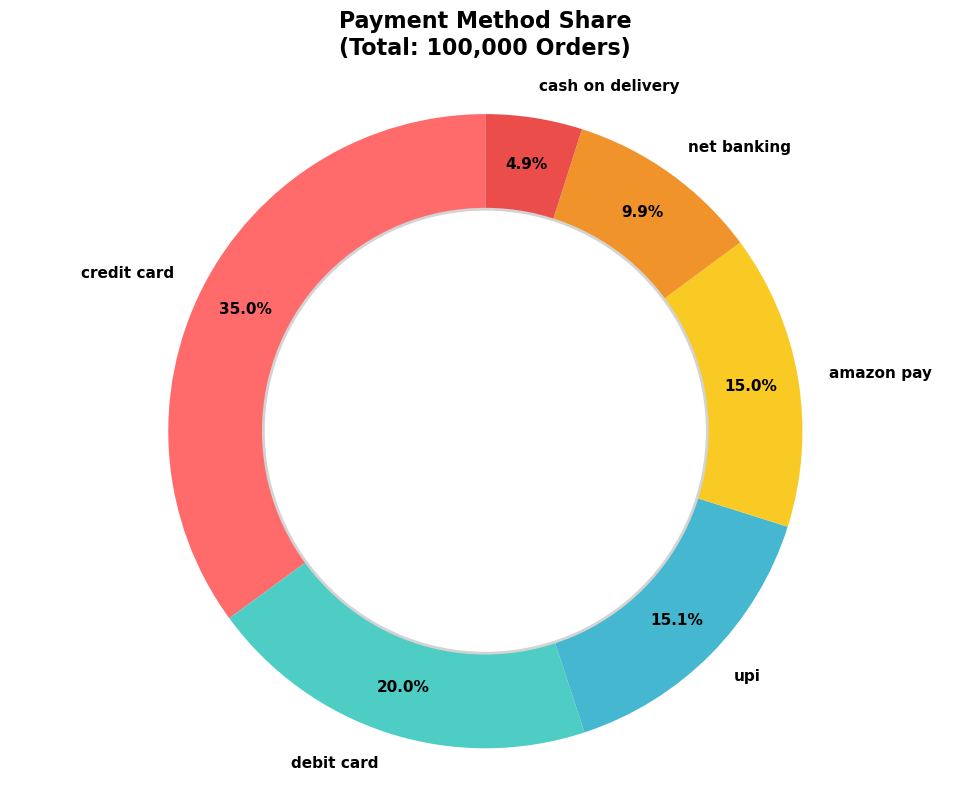

In [134]:
import matplotlib.pyplot as plt
import pandas as pd


df['PaymentMethod'] = df['PaymentMethod'].str.strip().str.lower()
payment_counts = df['PaymentMethod'].value_counts()


fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24', '#f0932b', '#eb4d4b']

wedges, texts, autotexts = ax.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)


centre_circle = plt.Circle((0, 0), 0.70, fc='white', linewidth=2, edgecolor='lightgray')
fig.gca().add_artist(centre_circle)


plt.title('Payment Method Share\n(Total: 100,000 Orders)', 
          fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')  
plt.tight_layout()
plt.show()


### Revenue by Country

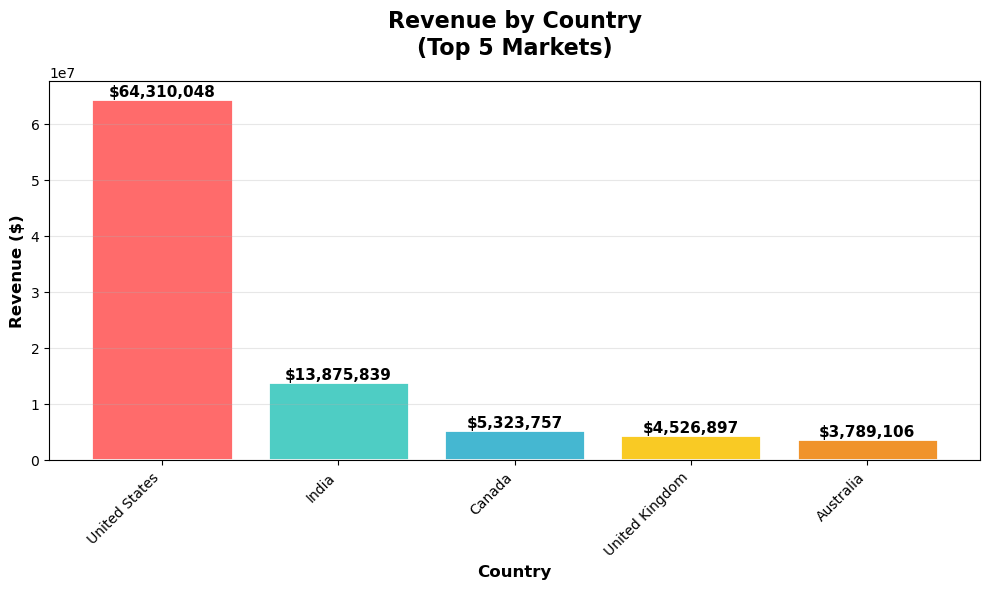

In [136]:
import matplotlib.pyplot as plt
import pandas as pd


country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 6))


bars = plt.bar(range(len(country_revenue)), country_revenue.values, 
               color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24', '#f0932b'],
               edgecolor='white', linewidth=2)

plt.title('Revenue by Country\n(Top 5 Markets)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Revenue ($)', fontsize=12, fontweight='bold')

plt.xticks(range(len(country_revenue)), country_revenue.index, rotation=45, ha='right')


for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'${height:,.0f}', ha='center', va='bottom', 
             fontweight='bold', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
